# Import Libraries

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", None)

# Load Dataset

In [194]:
df = pd.read_csv("../data/loan_dataset.csv")
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


# Dataset Understanding

In [195]:
df.shape

(32586, 13)

In [196]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  str    
 3   home_ownership       32586 non-null  str    
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  str    
 6   loan_grade           32586 non-null  str    
 7   loan_amnt            32585 non-null  str    
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  str    
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  str    
dtypes: float64(3), int64(3), str(7)
memory usage: 3.2 MB


In [197]:
print(df['loan_amnt'].head(20))
print(df['loan_amnt'].unique()[:20])

0     £35,000.00
1      £1,000.00
2      £5,500.00
3     £35,000.00
4     £35,000.00
5      £2,500.00
6     £35,000.00
7     £35,000.00
8     £35,000.00
9      £1,600.00
10    £35,000.00
11     £4,500.00
12    £35,000.00
13    £35,000.00
14    £35,000.00
15    £30,000.00
16    £35,000.00
17    £35,000.00
18    £35,000.00
19     £1,750.00
Name: loan_amnt, dtype: str
<StringArray>
['£35,000.00',  '£1,000.00',  '£5,500.00',  '£2,500.00',  '£1,600.00',
  '£4,500.00', '£30,000.00',  '£1,750.00', '£34,800.00', '£34,000.00',
  '£1,500.00', '£33,950.00', '£33,000.00',  '£4,575.00',  '£1,400.00',
 '£32,500.00',  '£4,000.00',  '£2,000.00', '£32,000.00', '£31,050.00']
Length: 20, dtype: str


# Data Cleaning

In [198]:
#Dropping customer_id column
df=df.drop('customer_id',axis=1)

In [199]:
# Cleaning LoanAmount column by removing currency symbols and commas
df['loan_amnt'] = pd.to_numeric(
    df['loan_amnt'].astype(str).str.replace(r"[£,]", "", regex=True),
    errors='coerce'
)
#Converting customer_income and loan_amnt to numeric columns
df['customer_income'] = pd.to_numeric(df['customer_income'],errors='coerce')
df['loan_amnt'] = pd.to_numeric(df['loan_amnt'],errors='coerce')

In [200]:
df['loan_amnt'].head(10)

0    35000.0
1     1000.0
2     5500.0
3    35000.0
4    35000.0
5     2500.0
6    35000.0
7    35000.0
8    35000.0
9     1600.0
Name: loan_amnt, dtype: float64

In [201]:
#Checking missing values
df.isnull().sum()

customer_age               0
customer_income            4
home_ownership             0
employment_duration      895
loan_intent                0
loan_grade                 0
loan_amnt                  1
loan_int_rate           3116
term_years                 0
historical_default     20737
cred_hist_length           0
Current_loan_status        4
dtype: int64

In [202]:
# Dropping records with missing target (Current_loan_status)
# Since target is essential for supervised learning, imputation is not appropriate
df=df.dropna(subset=['Current_loan_status'])

In [203]:
df.describe()

,customer_age,customer_income,employment_duration,loan_amnt,loan_int_rate,term_years,cred_hist_length
count,32582.000000,3.257800e+04,31687.000000,3.258100e+04,29467.000000,32582.00000,32582.000000
mean,27.732705,6.606776e+04,4.790009,9.756386e+03,11.011424,4.76131,5.803726
std,6.360909,6.197661e+04,4.142916,2.177317e+04,3.240462,2.47094,4.055203
min,3.000000,4.000000e+03,0.000000,5.000000e+02,5.420000,1.00000,2.000000
25%,23.000000,3.850000e+04,2.000000,5.000000e+03,7.900000,3.00000,3.000000
50%,26.000000,5.500000e+04,4.000000,8.000000e+03,10.990000,4.00000,4.000000
75%,30.000000,7.920000e+04,7.000000,1.220000e+04,13.470000,7.00000,8.000000
max,144.000000,6.000000e+06,123.000000,3.500000e+06,23.220000,10.00000,30.000000


In [204]:
#Target Distribution
df['Current_loan_status'].value_counts(normalize=True)*100

Current_loan_status
NO DEFAULT    79.006814
DEFAULT       20.993186
Name: proportion, dtype: float64

In [205]:
#Checking missing values
df.isnull().sum()

customer_age               0
customer_income            4
home_ownership             0
employment_duration      895
loan_intent                0
loan_grade                 0
loan_amnt                  1
loan_int_rate           3115
term_years                 0
historical_default     20737
cred_hist_length           0
Current_loan_status        0
dtype: int64

## Exploraratory Data Analysis


In [206]:
#Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cate_cols = df.select_dtypes(include = ['object']).columns

print("Numeric Columns")
print(num_cols)

print("Categorical Columns")
print(cate_cols)

Numeric Columns
Index(['customer_age', 'customer_income', 'employment_duration', 'loan_amnt',
       'loan_int_rate', 'term_years', 'cred_hist_length'],
      dtype='str')
Categorical Columns
Index(['home_ownership', 'loan_intent', 'loan_grade', 'historical_default',
       'Current_loan_status'],
      dtype='str')


C:\Users\user\AppData\Local\Temp\ipykernel_8108\1604427785.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cate_cols = df.select_dtypes(include = ['object']).columns


In [207]:
# Missing value percentage
missing_percent = df.isnull().mean()*100
missing_percent[missing_percent>0].sort_values(ascending=False)

historical_default     63.645571
loan_int_rate           9.560494
employment_duration     2.746915
customer_income         0.012277
loan_amnt               0.003069
dtype: float64

In [208]:
print(df.groupby(by='historical_default')['Current_loan_status'].value_counts())

historical_default  Current_loan_status
N                   DEFAULT                4568
                    NO DEFAULT             1149
Y                   NO DEFAULT             3856
                    DEFAULT                2272
Name: count, dtype: int64


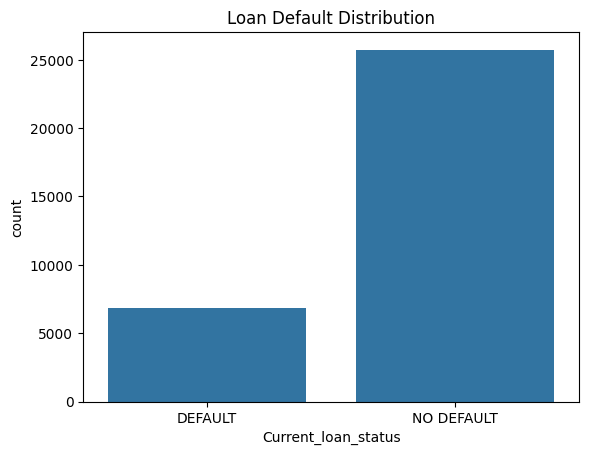

In [209]:
#Target Distribution Visualization
sns.countplot(x="Current_loan_status",data = df )
plt.title("Loan Default Distribution")
plt.show()

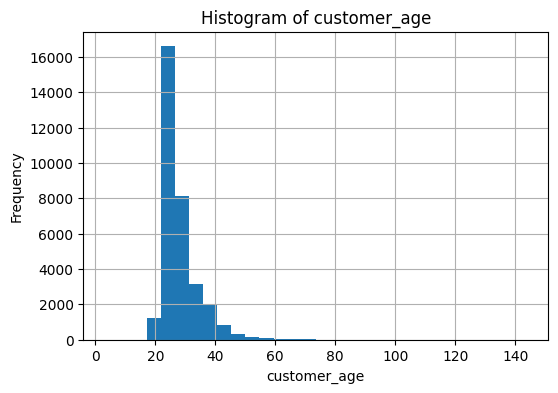

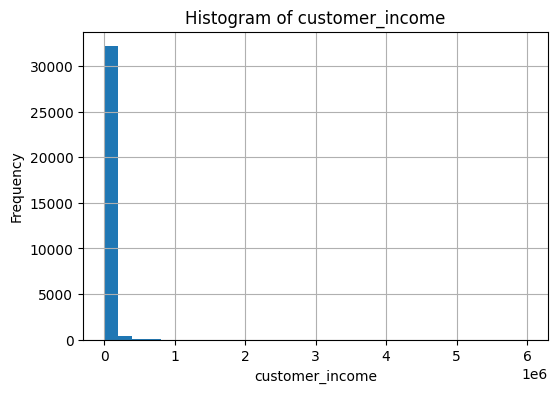

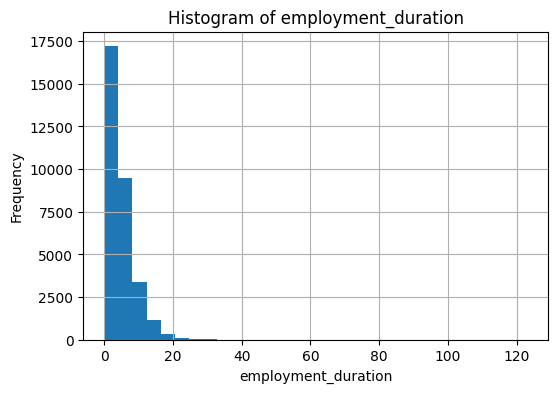

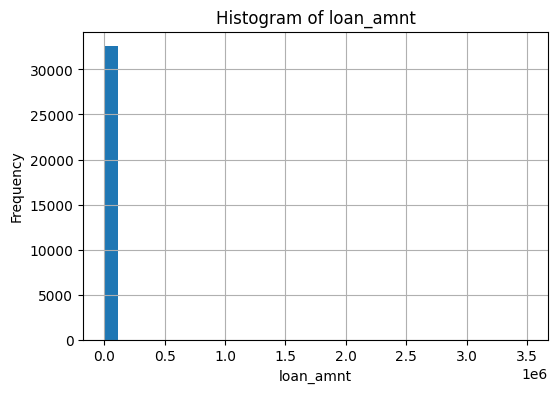

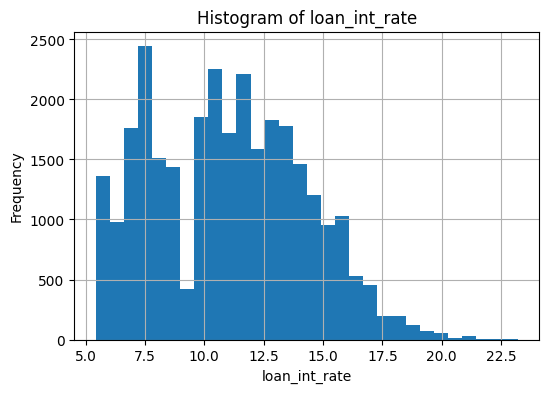

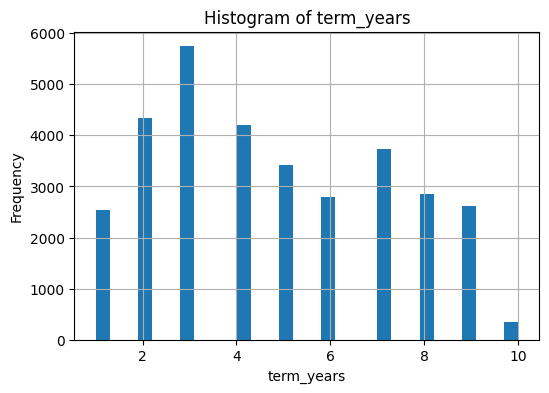

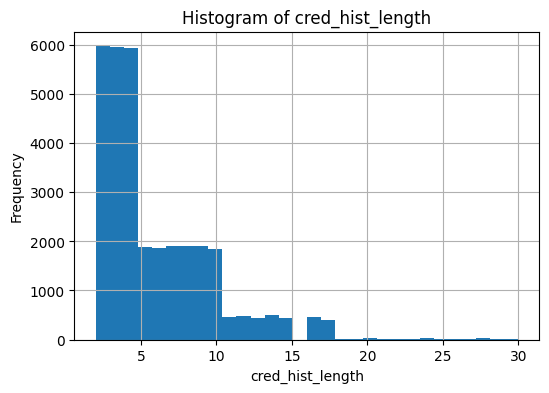

In [210]:
#Numerical Column Analysis
for col in num_cols:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

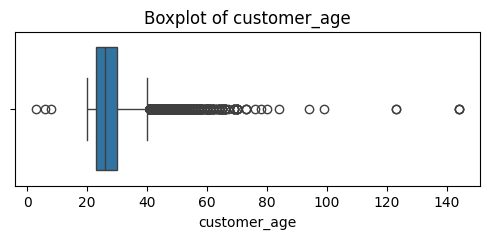

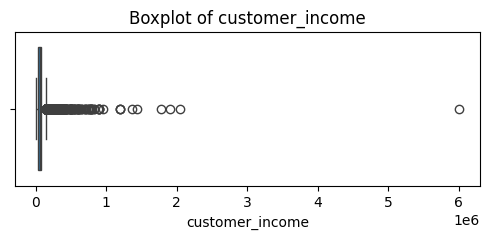

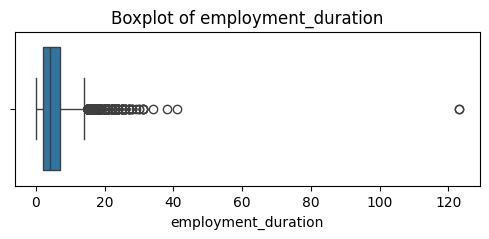

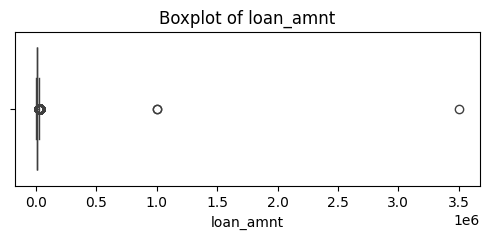

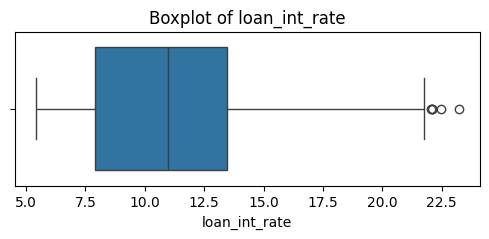

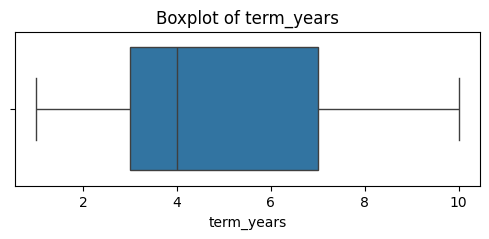

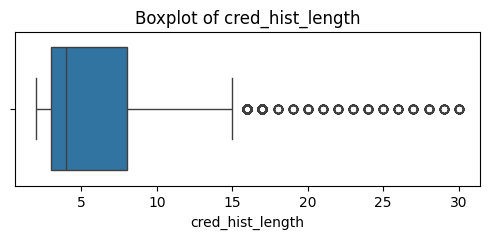

In [211]:
for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

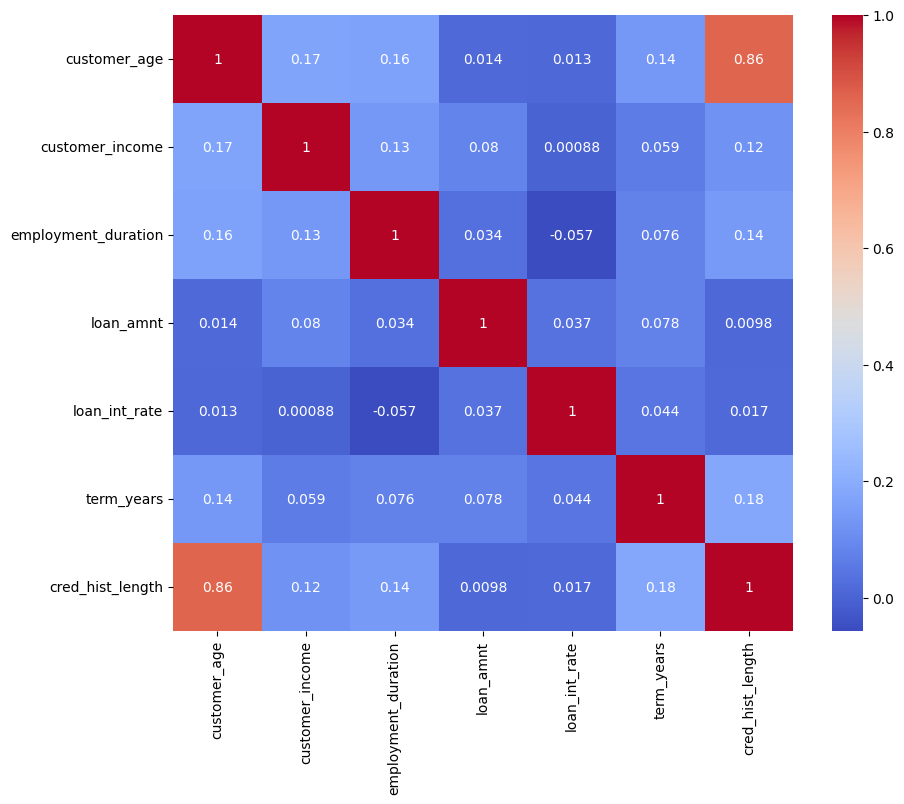

In [212]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

In [213]:
#Categorical Columns analysis
for col in cate_cols:
    print(df[col].value_counts())
    print("-" * 30)

home_ownership
RENT        16449
MORTGAGE    13443
OWN          2583
OTHER         107
Name: count, dtype: int64
------------------------------
loan_intent
EDUCATION            6453
MEDICAL              6072
VENTURE              5717
PERSONAL             5521
DEBTCONSOLIDATION    5213
HOMEIMPROVEMENT      3606
Name: count, dtype: int64
------------------------------
loan_grade
A    15660
B     9064
C     4925
D     2628
E      305
Name: count, dtype: int64
------------------------------
historical_default
Y    6128
N    5717
Name: count, dtype: int64
------------------------------
Current_loan_status
NO DEFAULT    25742
DEFAULT        6840
Name: count, dtype: int64
------------------------------


# Dataset split into train and test


In [214]:
# Separating independent features and target variable
X = df.drop('Current_loan_status', axis=1)
y = df['Current_loan_status']

In [215]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [216]:
print(X_train.shape,X_test.shape)
print(y_train.shape, y_test.shape)

(26065, 11) (6517, 11)
(26065,) (6517,)


In [217]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Current_loan_status
NO DEFAULT    0.790063
DEFAULT       0.209937
Name: proportion, dtype: float64
Current_loan_status
NO DEFAULT    0.790087
DEFAULT       0.209913
Name: proportion, dtype: float64


# Data Preprocessing Pipeline

In [232]:
df[num_cols].columns

Index(['customer_age', 'customer_income', 'employment_duration', 'loan_amnt',
       'loan_int_rate', 'term_years', 'cred_hist_length'],
      dtype='str')

In [233]:
df[cate_cols].columns

Index(['home_ownership', 'loan_intent', 'loan_grade', 'historical_default',
       'Current_loan_status'],
      dtype='str')

In [245]:
ordinal_cols = ['loan_grade']

onehot_cols = ['home_ownership','loan_intent','historical_default']

In [235]:
X["loan_grade"].nunique()


5

In [ ]:
#Numerical feature preprocessing pipeline
num_pipeline =Pipeline (
    [
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())
    ]
)

In [242]:
#Nominal feature preprocessing pipeline
onehot_pipeline = (
    [
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [243]:
#Ordinal feature preprocessing pipeline
ordinal_pipeline = (
    [
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OrdinalEncoder(categories=[["A","B","C","D","E"]]))
    ]
)

In [246]:
#Combine preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", onehot_pipeline, onehot_cols),
    ("ord", ordinal_pipeline, ordinal_cols)
])

In [ ]:
#Final ML pipeline

model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

In [248]:
#Train 
model.fit(X_train,y_train)

TypeError: All estimators should implement fit and transform, or can be 'drop' or 'passthrough' specifiers. '[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]' (type <class 'list'>) doesn't.

In [ ]:
#Predict
y_pred = model.predict(X_test)